In [1]:
import pickle
from pathlib import Path

DATA_DIR = Path("../data/per_machine")

machine = "machine-1-1"

with open(DATA_DIR / f"{machine}_train.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(DATA_DIR / f"{machine}_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open(DATA_DIR / f"{machine}_test_label.pkl", "rb") as f:
    y_test = pickle.load(f)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Label shape:", y_test.shape)
print("Anomaly points in test:", y_test.sum())

Train shape: (28479, 38)
Test shape: (28479, 38)
Label shape: (28479,)
Anomaly points in test: 2694.0


In [2]:
import numpy as np

print("Train dtype:", X_train.dtype)
print("Test dtype:", X_test.dtype)
print("Label unique values:", np.unique(y_test))

print("Train min/max:", np.min(X_train), np.max(X_train))
print("Test min/max:", np.min(X_test), np.max(X_test))

Train dtype: float32
Test dtype: float32
Label unique values: [0. 1.]
Train min/max: 0.0 1.0
Test min/max: 0.0 1.0


In [3]:
import pandas as pd

train_df = pd.DataFrame(X_train)
summary = train_df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
0,28479.0,0.064195,0.056685,0.000000,0.032258,0.043011,0.086022,0.494624
1,28479.0,0.056882,0.042515,0.000000,0.027542,0.045551,0.075212,0.421610
2,28479.0,0.053549,0.037695,0.000000,0.027871,0.042363,0.070234,0.278707
3,28479.0,0.050188,0.037443,0.000000,0.024390,0.037166,0.067364,0.250871
4,28479.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,28479.0,0.913552,0.037972,0.000000,0.907692,0.912821,0.920513,1.000000
6,28479.0,0.262274,0.066661,0.000000,0.251412,0.274011,0.311676,0.360640
7,28479.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,28479.0,0.020346,0.009982,0.000000,0.012347,0.021005,0.027959,0.118081
9,28479.0,0.000159,0.001288,0.000000,0.000000,0.000000,0.000122,0.140435


In [4]:
test_df = pd.DataFrame(X_test)

train_nan_counts = train_df.isna().sum()
test_nan_counts = test_df.isna().sum()

features_with_nan = [
    col for col in train_df.columns
    if train_nan_counts[col] > 0 or test_nan_counts[col] > 0
]

print("Features with NaN values:", features_with_nan)
print("Total NaN values in train:", train_df.isna().sum().sum())
print("Total NaN values in test:", test_df.isna().sum().sum())

Features with NaN values: []
Total NaN values in train: 0
Total NaN values in test: 0


In [5]:
constant_features = summary[summary["std"] == 0].index.tolist()
print("Constant features:", constant_features)
print("Number of constant features:", len(constant_features))

train_df_reduced = train_df.drop(columns=constant_features)

print("Reduced shape:", train_df_reduced.shape)
print("Remaining features:", train_df_reduced.columns.tolist())

Constant features: [4, 7, 16, 17, 26, 28, 36, 37]
Number of constant features: 8
Reduced shape: (28479, 30)
Remaining features: [0, 1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 23, 24, 25, 27, 29, 30, 31, 32, 33, 34, 35]


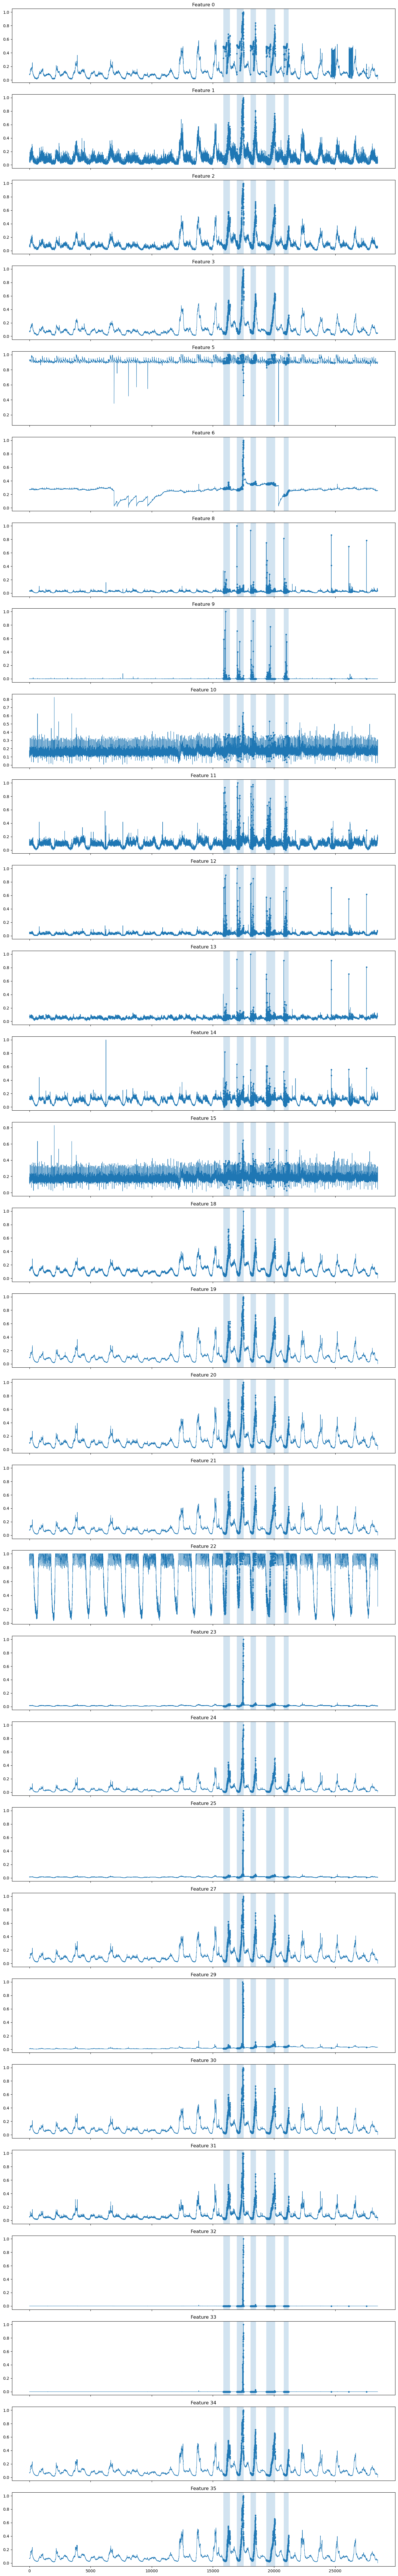

In [6]:
import matplotlib.pyplot as plt

features_to_plot = train_df_reduced.columns.tolist()

intervals = []
in_interval = False
start = None

for i, val in enumerate(y_test):
    if val == 1 and not in_interval:
        start = i
        in_interval = True
    elif val == 0 and in_interval:
        intervals.append((start, i - 1))
        in_interval = False

if in_interval:
    intervals.append((start, len(y_test) - 1))

fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(14, 3 * len(features_to_plot)), sharex=True)

for ax, feat in zip(axes, features_to_plot):
    ax.plot(X_test[:, feat], linewidth=0.8)
    anomaly_idx = np.where(y_test == 1)[0]
    ax.scatter(anomaly_idx, X_test[anomaly_idx, feat], s=8)

    for start, end in intervals:
        ax.axvspan(start, end, alpha=0.2)

    ax.set_title(f"Feature {feat}")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

interval_lengths = [end - start + 1 for start, end in intervals]

interval_gaps = [
    next_start - prev_end - 1
    for (_, prev_end), (next_start, _) in zip(intervals[:-1], intervals[1:])
]

print("Intervals:", intervals)
print("Number of intervals:", len(intervals))
print("Interval lengths:", interval_lengths)

print("\nInterval length statistics:")
print("Mean length:", np.mean(interval_lengths))
print("Median length:", np.median(interval_lengths))
print("Min length:", np.min(interval_lengths))
print("Max length:", np.max(interval_lengths))
print("Std length:", np.std(interval_lengths))

print("\nGaps between intervals:", interval_gaps)
if interval_gaps:
    print("\nGap statistics:")
    print("Mean gap:", np.mean(interval_gaps))
    print("Median gap:", np.median(interval_gaps))
    print("Min gap:", np.min(interval_gaps))
    print("Max gap:", np.max(interval_gaps))
    print("Std gap:", np.std(interval_gaps))

Intervals: [(15849, 16394), (16963, 17516), (18071, 18527), (19367, 20087), (20786, 21194), (24679, 24681), (26114, 26115), (27554, 27555)]
Number of intervals: 8
Interval lengths: [546, 554, 457, 721, 409, 3, 2, 2]

Interval length statistics:
Mean length: 336.75
Median length: 433.0
Min length: 2
Max length: 721
Std length: 272.44621028746207

Gaps between intervals: [568, 554, 839, 698, 3484, 1432, 1438]

Gap statistics:
Mean gap: 1287.5714285714287
Median gap: 839.0
Min gap: 554
Max gap: 3484
Std gap: 961.5840884621966


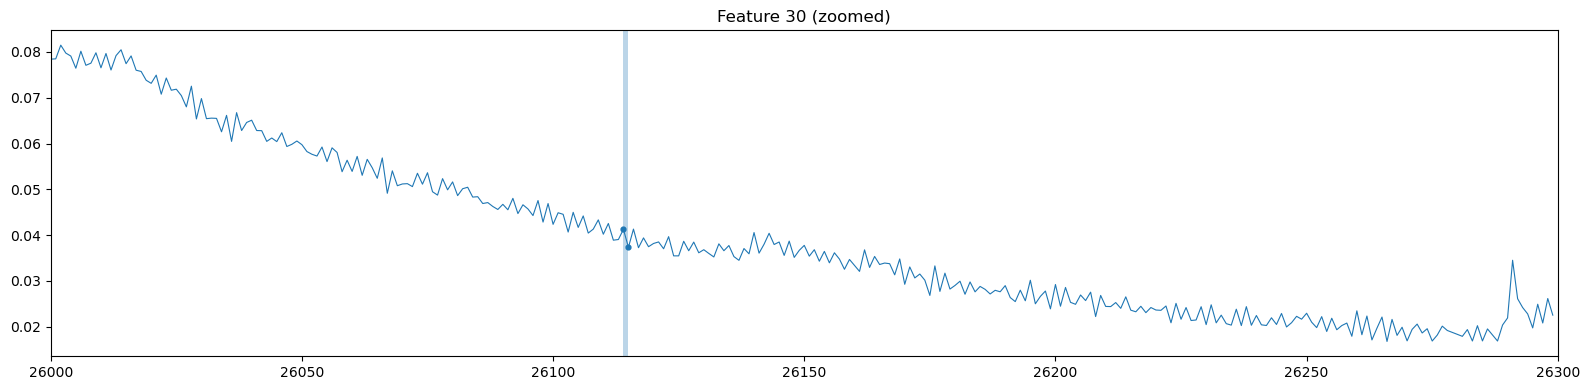

In [12]:
import matplotlib.pyplot as plt
import numpy as np

feat = 30
left = 26000
right = 26300

plt.figure(figsize=(16, 4))
plt.plot(range(left, right), X_test[left:right, feat], linewidth=0.8)

for start, end in intervals:
    if end >= left and start <= right:
        plt.axvspan(start, end, alpha=0.3)

anomaly_idx = np.where(y_test == 1)[0]
anomaly_idx_zoom = anomaly_idx[(anomaly_idx >= left) & (anomaly_idx < right)]
plt.scatter(anomaly_idx_zoom, X_test[anomaly_idx_zoom, feat], s=12)

plt.title(f"Feature {feat} (zoomed)")
plt.xlim(left, right)
plt.tight_layout()
plt.show()

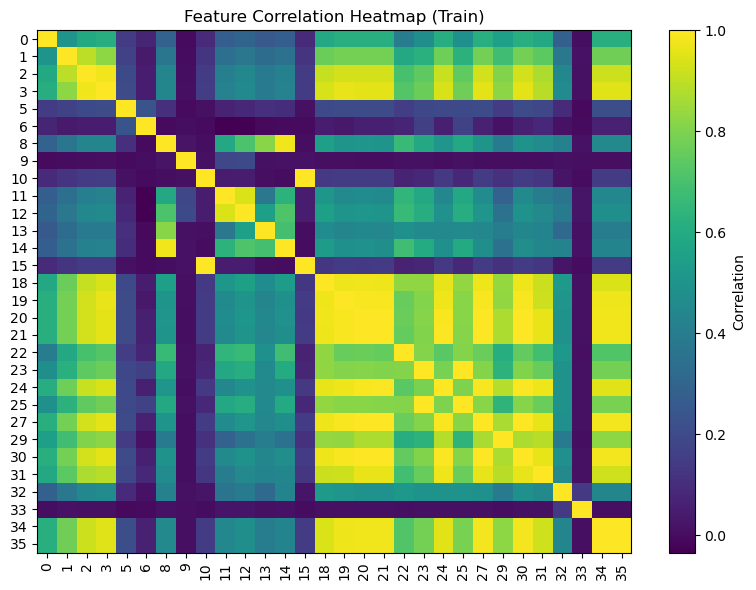

In [9]:
import matplotlib.pyplot as plt
import numpy as np

corr = train_df_reduced.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Feature Correlation Heatmap (Train)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()